blau: 29.0 cm, 314.0 g
negre: 34.7 cm, 527.2 g
blanc: 35.1 cm, 572.9 g
vermell: 34.2 cm, 476.5 g

In [1]:
!pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from openpyxl import load_workbook
from pandas import ExcelWriter



# 1) Lubina -> 33,5 cm (tail included) // 30,0 cm (without tail)
# 2) Ocha1 -> 33,5 cm (tail included) // 28,0 cm (without tail) // clip ->>>> Corregit!! cinta americana
# 3) Ocha2 -> 30,0 cm (tail included) // 25,0 cm (without tail) // 

# Notes whatsap:
# Lubina 
# 33.75-8 total 
# Fins enmig de la cia 32cm
# Fins a la cosa 28.5

# Peix cinta americana :
# 33.8
# Sense la mini coa 31.9 
# Fins a la coa 28.4

# Peix 2 sense cinta americana:
# 30.8-9
# 26 sense la coa

In [3]:
# INIT

In [2]:
def clasificar_medidas(df, agg=False, verbose=True):
    df = df.copy()

    def clasificar_error(x, umbral_good, umbral_medium):
        return 'good' if x < umbral_good else ('medium' if x < umbral_medium else 'bad')

    if agg:
        columnas = {
            'measure_ok_abs_max': ('Abs_ERROR (maxl) [cm]', 1, 2),
            'measure_ok_abs_mean': ('Abs_ERROR (meanl) [cm]', 1, 2),
            'measure_ok_rel_max': ('relative_error(maxl) [%]', 1, 5),
            'measure_ok_rel_mean': ('relative_error(meanl) [%]', 1, 5),
        }
        for nueva_col, (col, umbral_good, umbral_medium) in columnas.items():
            df[nueva_col] = df[col].apply(lambda x: clasificar_error(x, umbral_good, umbral_medium))

        if verbose:
            print("Resumen de clasificaciones (agregadas):\n")
            for col in columnas.keys():
                counts = df[col].value_counts()
                percentages = df[col].value_counts(normalize=True) * 100
                print(f"{col}:")
                print(counts)
                print("%", percentages.round(2), "\n")
                print("-" * 80)

    else:
        columnas = {
            'measure_ok_abs': ('Abs_ERROR [cm]', 1, 2),
            'measure_ok_rel': ('Rel_ERROR[%]', 1, 5),
        }
        for nueva_col, (col, umbral_good, umbral_medium) in columnas.items():
            df[nueva_col] = df[col].apply(lambda x: clasificar_error(x, umbral_good, umbral_medium))

        if verbose:
            print(df.head(), "\n")
            print(df.describe(), "\n")

            for col in columnas.keys():
                counts = df[col].value_counts()
                percentages = df[col].value_counts(normalize=True) * 100
                print(f"{col}:")
                print(counts)
                print("%", percentages.round(2), "\n")
                print("-" * 80)

    return df
    
def generate_analysis_plots(df):
    # Preprocessing (if not already done)
    df["elevation_abs"] = df["elevation_deg"].abs()
    df["elevation_rad"] = np.radians(df["elevation_deg"])
    df["elevation_sin"] = np.abs(np.sin(df["elevation_rad"]))
    
    # Define error metric and label column
    error_col = "Abs_ERROR [cm]"
    label_col = "measure_ok_abs"  # Make sure this column is present in your df
    
    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(16, 6))
    
    # Plot 1: "Error vs Absolute Elevation Angle
    sns.scatterplot(x="elevation_abs", y=error_col, hue=label_col, data=df, ax=axs[0], palette="Set2", s=70)
    axs[0].set_title("Error vs Absolute Elevation Angle")
    axs[0].set_xlabel("|Elevation| (degrees)")
    axs[0].set_ylabel(error_col)
    axs[0].grid(True)
    
    # Plot 2: Error vs sin(|Elevation|)
    sns.scatterplot(x="elevation_sin", y=error_col, hue=label_col, data=df, ax=axs[1], palette="Set2", s=70)
    axs[1].set_title("Error vs sin(|Elevation|)")
    axs[1].set_xlabel("sin(|elevation|) [0: side-view, 1: head/tail-view]")
    axs[1].set_ylabel(error_col)
    axs[1].grid(True)
    
    # Plot 3: Error vs fish_dist_from_camera
    sns.scatterplot(x="fish_dist_from_camera",y=error_col,hue=label_col,data=df, ax=axs[2],palette="Set2",s=70)
    axs[2].set_title("Error vs fish_dist_from_camera")
    axs[2].set_xlabel("fish_dist_from_camera")  # Fixed: removed extra parenthesis
    axs[2].set_ylabel(error_col)
    axs[2].grid(True)
    
    
    plt.tight_layout()
    plt.legend(title="Quality Label")
    plt.show()

    return df 
    
# Function to color rows according to measure classification
def highlight_rows(row,quality_column="measure_ok_abs_max"):

    if row[quality_column]=='good':
         color = '#d9f2d9'  # soft green
    elif row[quality_column]=='medium':
        color = '#fff3cd'  # soft orange/yellow
    elif row[quality_column]=='bad':
         color = '#f8d7da'  # soft red/pink
    else:
        print("PROBLEM!!")
        color ="white"
    return [f'background-color: {color}'] * len(row)


def visualizar_outliers(df, track_id, porcentaje_umbral=0.1):
    grupo = df[df['track_id'] == track_id]
    valores = grupo['filtered_length'].sort_values(ascending=False).reset_index(drop=True)
    print("num de medidas = ",len(valores))

    media = valores.mean()
    threshold = porcentaje_umbral * media
    
    outlier_indices = []
    for i in range(len(valores) - 1):
        diff = valores[i] - valores[i + 1]
        if not ((diff <= porcentaje_umbral * media) or diff <0.03):
            print("DIFF:",diff)
            print("THR:",threshold)
            
            outlier_indices.append(i)

    # Marcar valores como outliers o no
    colores = ['red' if i in outlier_indices else 'skyblue' for i in range(len(valores))]

    # Visualización detallada
    plt.figure(figsize=(12, 6))
    plot = plt.scatter(range(len(valores)), valores, color=colores, edgecolor='black')
    plt.title(f'Valores ordenados de filtered_length para track_id: {track_id}')
    plt.xlabel('Índice (ordenado descendente)')
    plt.ylabel('filtered_length')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def filtrar_outliers(grupo,porcentaje_umbral=0.05):
    valores = grupo['filtered_length'].sort_values(ascending=False).reset_index(drop=True)
    if len(valores) <= 2:
        return pd.DataFrame({'filtered_length': [valores.iloc[0]], 'track_id': grupo.name})
    
    media = valores.mean()
    for i in range(len(valores) - 1):
        diff = valores.iloc[i] - valores.iloc[i + 1]
        if (diff <= porcentaje_umbral * media) or diff <0.03:
            return pd.DataFrame({'filtered_length': [valores.iloc[i]], 'track_id': grupo.name})
        else: 
            print("*****************************************")
            print("Maximo descartado",valores.iloc[i])
            print("*****************************************")
    return pd.DataFrame({'filtered_length': [valores.iloc[-1]], 'track_id': grupo.name})

def descartar_outliers_por_track(df, porcentaje_umbral=0.05):
    # Aplicar filtrado
    df_max_filtrados = (
    df.groupby('track_id', group_keys=False)
      .apply(filtrar_outliers)
      .reset_index(drop=True))

    # Asociar las medidas gt_measure a cada track_id
    gt_measure = bagfile_gts[base_path]
    print(gt_measure)
    
    # Asignar al dataframe filtrado
    # df_max_filtrados["gt_measure"] = df_max_filtrados["track_id"].map(gt_measure)
    print("peix_measures",peix_measures)
    df_max_filtrados["gt_measure"] = df_max_filtrados["track_id"].map(gt_measure).map(peix_measures)
    df_max_filtrados['codi_escenari'] = codi_escenari
    df_max_filtrados['day'] = day
    df_max_filtrados['hour'] = hour
    
    # # Calcular el error absoluto en cm
    df_max_filtrados["Abs_ERROR [cm]"] = abs(df_max_filtrados["filtered_length"] - (df_max_filtrados["gt_measure"] / 100)) * 100
    # # Calcular el error relativo en porcentaje
    df_max_filtrados['relative_error [%]'] = df_max_filtrados["Abs_ERROR [cm]"] / (df_max_filtrados['gt_measure'] / 100)
    # Clasificación en datos agregados (por track_id)
    
    df_max_filtrados['measure_ok_abs'] = df_max_filtrados['Abs_ERROR [cm]'].apply(
        lambda x: 'good' if x < 1 else ('medium' if x <= 2 else 'bad')

    )
    print("------------------------------------------------------------------")
    print(df_max_filtrados)
    print("------------------------------------------------------------------")
    
    
    # Calcular estadísticas por track_id
    df_statistics = df.groupby('track_id', as_index=False).agg(
        count=('filtered_length', 'size'),
        max_length=('filtered_length', 'max'),
        mean_length=('filtered_length', 'mean'),
        elevation_deg_mean=('elevation_deg', 'mean'),
        std_dev=('filtered_length', 'std')
    )
    
    # Combinar stats con datos filtrados
    df_resultado = df_max_filtrados.merge(df_statistics, on='track_id', how='left')
    print(df_resultado.columns)

    column_order = [
        "codi_escenari",
        "day",
        "hour",        
        "track_id",
        "count",
        "filtered_length",
        "gt_measure",
        "Abs_ERROR [cm]",
        "relative_error [%]",
        "measure_ok_abs",
        "max_length",
        "mean_length",
        "std_dev",
        "elevation_deg_mean"
    ]
    
    df_resultado = df_resultado[column_order]

    return df_resultado



def guardar_resultado_excel(df, filename, sheet_name="resultados"):
    if os.path.exists(filename):
        # Si el archivo existe, abre y añade nueva hoja
        with ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='new') as writer:
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    else:
        # Si no existe, lo crea desde cero
        df.to_excel(filename, sheet_name=sheet_name, index=False)
        

In [5]:
peix_measures={"blau": 29.0 , 
                    "negre": 34.7 , 
                    "blanc": 35.1 , 
                    "vermell": 34.2 , 
               "unknown":-100}


bagfile_gts={"2024_11_27/12_09_14":{-1:"unknown", 26:"blanc", 194:"blanc", 200:"vermell", 209:"negre", 227:"unknown", 256:"unknown", 264:"vermell", 267:"negre",\
314:"vermell", 315:"unknown", 348:"negre", 355:"negre"}}

Tracks ids present in this video:
{256, 194, 227, 355, 200, 264, 267, 314, 209, 26, 315, 348, -1}
{-1: 'unknown', 26: 'blanc', 194: 'blanc', 200: 'vermell', 209: 'negre', 227: 'unknown', 256: 'unknown', 264: 'vermell', 267: 'negre', 314: 'vermell', 315: 'unknown', 348: 'negre', 355: 'negre'}
  codi_escenari         day      hour  frame_id  class_name  Object_id  \
0            El  2024_11_27  12_09_14   frame46           9         85   
1            El  2024_11_27  12_09_14  frame218           9        170   
2            El  2024_11_27  12_09_14  frame219           9        170   
3            El  2024_11_27  12_09_14  frame223           9        255   
4            El  2024_11_27  12_09_14  frame224           9        255   

   track_id  is_3D_complete  in_image_borders  \
0        26               1             False   
1       194               1             False   
2       194               1             False   
3       200               1             False   
4       200      

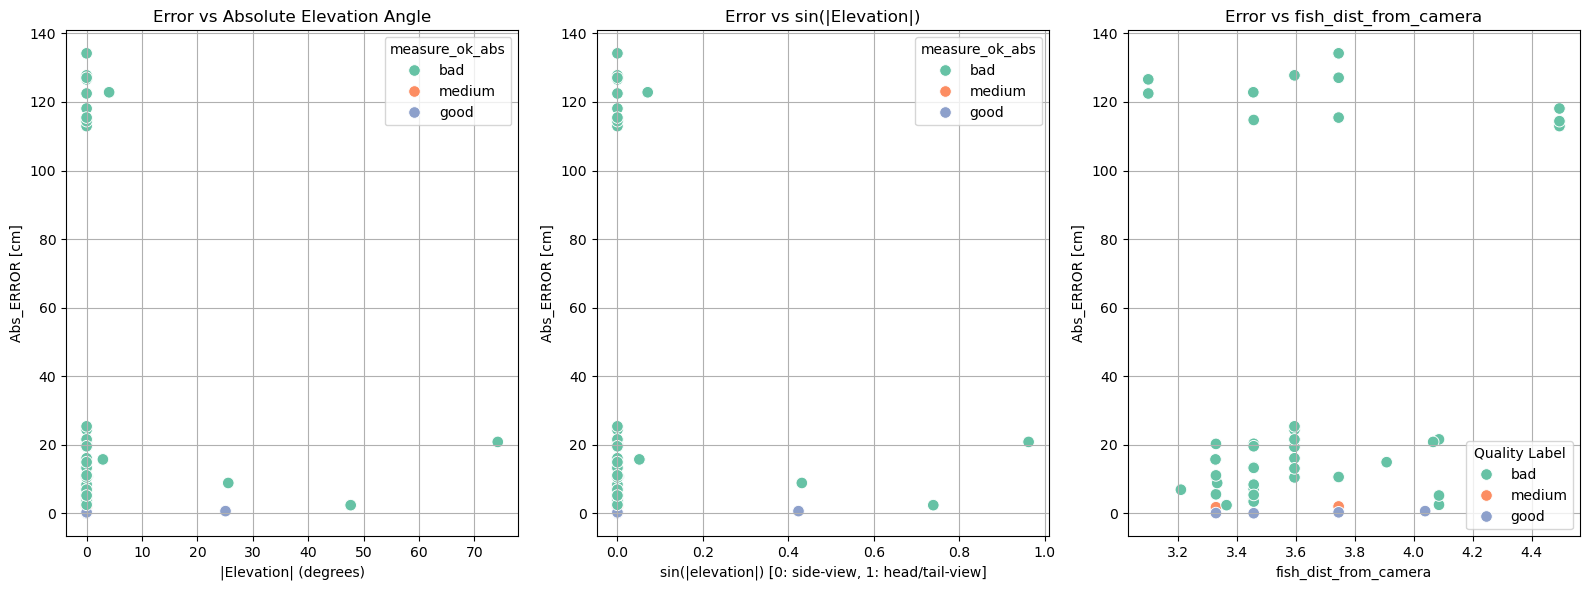

*****************************************
Maximo descartado 0.3419006613415846
*****************************************
*****************************************
Maximo descartado 0.5591101776567897
*****************************************
*****************************************
Maximo descartado 0.1354676262955027
*****************************************
*****************************************
Maximo descartado 0.4303222911351301
*****************************************
*****************************************
Maximo descartado 0.3470664084842474
*****************************************
*****************************************
Maximo descartado 0.3127878195405261
*****************************************
*****************************************
Maximo descartado 0.3221252140969387
*****************************************
*****************************************
Maximo descartado 0.2935790240128633
*****************************************
{-1: 'unknown', 26: 'blanc', 194

/tmp/ipykernel_2785440/2128013161.py:156: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(filtrar_outliers)


In [7]:
# INICIALITZACIONS -----------------------------------------------------------
Escenari="Escenari_llobarros/"
base_path="2024_11_27/12_09_14"

column_order = [
    "codi_escenari",
    "day",
    "hour",        
    "track_id",
    "count",
    "filtered_length",
    "gt_measure",
    "Abs_ERROR [cm]",
    "relative_error [%]",
    "measure_ok_abs",
    "max_length",
    "mean_length",
    "std_dev",
    "elevation_deg_mean",
    "comentaris"
]

df_all_results = pd.DataFrame(columns=column_order)


day = base_path.split("/")[0]
hour = base_path.split("/")[-1]
codi_escenari="E"+Escenari.split("_")[-1][0]

temp_code = ("-").join(base_path.split("/"))
experiment_code = codi_escenari+"_"+temp_code


out_escenari_agg_csv=codi_escenari+"_results_resume.csv"
out_csv_name =experiment_code+"_results_agg.csv"

df = pd.read_csv(Escenari+base_path+"/pointclouds/results/all_complete_ok_fish.csv").iloc[:,1:]
df_resume = pd.read_csv(Escenari+base_path+"/pointclouds/results/resume.csv")

df['codi_escenari'] = codi_escenari
df['day'] = day
df['hour'] = hour

# Paso 3: Reordenar columnas (poner las nuevas al principio)
cols = ['codi_escenari', 'day', 'hour'] + [col for col in df.columns if col not in ['codi_escenari', 'day', 'hour']]
df = df[cols]

peix_measures={"blau": 29.0 , 
                    "negre": 34.7 , 
                    "blanc": 35.1 , 
                    "vermell": 34.2 , 
               "unknown":-100}


bagfile_gts={"2024_11_27/12_09_14":{-1:"unknown", 26:"blanc", 194:"blanc", 200:"vermell", 209:"negre", 227:"unknown", 256:"unknown", 264:"vermell", 267:"negre",\
314:"vermell", 315:"unknown", 348:"negre", 355:"negre"}}

print("Tracks ids present in this video:")
print(set(df["track_id"]))

# Ja he generat el gt
if base_path in bagfile_gts.keys():

    gt_measure = bagfile_gts[base_path]
    print(gt_measure)
        
    
    df["gt_measure"] = df["track_id"].map(gt_measure).map(peix_measures)
    df_resume["gt_measure"] = df_resume["track_id"].map(gt_measure).map(peix_measures)
    # df_resume["gt_measure"] = df["track_id"].map(gt_measure[peix_measures])
    df.sort_values(by=['frame_id'])

    df["Abs_ERROR [cm]"]=abs(df["filtered_length"]-(df["gt_measure"]/100))*100
    df['Rel_ERROR[%]'] = df['Abs_ERROR [cm]'] / (df['gt_measure']/100)

    print(df.head())
    print("----------------------------------- \n \n")

    df = clasificar_medidas(df, agg=False)
    # print(df.head())
    
    df = generate_analysis_plots(df)

    # Descomentar para guardar todas las medidas sin agregar clasificadas:
    # styled_df = df.style.apply(lambda row: highlight_rows(row, quality_column="measure_ok_abs"), axis=1)
    # styled_df.to_excel(out_csv_name+'.xlsx', engine='openpyxl', index=False)

    df_resultado=descartar_outliers_por_track(df, porcentaje_umbral=0.1)
    print(df_resultado.head())
    

    df_resultado["Comentaris"] = ("")
    # df_resultado.loc[df_resultado["track_id"] != 1, "Comentaris"] = ("")

    df_resultado_colored = df_resultado.style.apply(lambda row: highlight_rows(row, quality_column='measure_ok_abs'), axis=1)
    
    





In [8]:
df_resultado_colored

,codi_escenari,day,hour,track_id,count,filtered_length,gt_measure,Abs_ERROR [cm],relative_error [%],measure_ok_abs,max_length,mean_length,std_dev,elevation_deg_mean,Comentaris
0,El,2024_11_27,12_09_14,-1,7,0.277670,-100.000000,127.766973,-127.766973,bad,0.341901,0.228244,0.072328,0.000000,
1,El,2024_11_27,12_09_14,26,1,0.135924,35.100000,21.507562,61.275105,bad,0.135924,0.135924,nan,-0.000000,
2,El,2024_11_27,12_09_14,194,3,0.097402,35.100000,25.359763,72.250037,bad,0.559110,0.263993,0.256286,-24.735402,
3,El,2024_11_27,12_09_14,200,13,0.365613,34.200000,2.361262,6.904274,bad,0.430322,0.246386,0.103098,-1.484311,
4,El,2024_11_27,12_09_14,209,4,0.275391,34.700000,7.160896,20.636588,bad,0.347066,0.299684,0.037933,-0.000000,
5,El,2024_11_27,12_09_14,227,1,0.228263,-100.000000,122.826339,-122.826339,bad,0.228263,0.228263,nan,-4.062265,
6,El,2024_11_27,12_09_14,256,2,0.144010,-100.000000,114.400987,-114.400987,bad,0.144010,0.136797,0.010201,-0.000000,
7,El,2024_11_27,12_09_14,264,4,0.237408,34.200000,10.459202,30.582462,bad,0.322125,0.244322,0.058037,0.000000,
8,El,2024_11_27,12_09_14,267,5,0.216055,34.700000,13.094547,37.736448,bad,0.293579,0.201462,0.063727,-0.000000,
9,El,2024_11_27,12_09_14,314,2,0.273281,34.200000,6.871861,20.093160,bad,0.273281,0.252401,0.029529,-0.000000,


In [9]:
peix_measures

{'blau': 29.0, 'negre': 34.7, 'blanc': 35.1, 'vermell': 34.2, 'unknown': -100}

In [36]:
# Afegir comentari si toca 
df_resultado.loc[df_resultado["track_id"] == 34, "Comentaris"] = ("No és un peix real...")
# df_resultado["Comentaris"] = ("Aquest dataset no és el millor perquè es mesclen ids...")

In [40]:

# Guardar con append o crear nuevo
df_resultado.to_csv(experiment_code+".csv")
df_resultado_colored.to_excel(experiment_code+'.xlsx', engine='openpyxl', index=False)

# Append df del escenario y guardar:
df_all_results = pd.concat([df_escenari_results, df_resultado], ignore_index=True)

csv_path = codi_escenari + ".csv"
# Comprobar si el archivo ya existe
file_exists = os.path.exists(csv_path)
# Guardar con append o crear nuevo
df_all_results.to_csv(
    csv_path,
    mode='a' if file_exists else 'w',
    header=not file_exists,  # Solo escribir encabezado si el archivo no existe
    index=False
)

# Apply styling and save
df_all_results_colored = df_all_results.style.apply(lambda row: highlight_rows(row, quality_column='measure_ok_abs'), axis=1)
df_all_results_colored.to_excel(experiment_code+'.xlsx', engine='openpyxl', index=False)

df_all_results_colored.to_excel(codi_escenari+'.xlsx', engine='openpyxl', index=False)







/tmp/ipykernel_2399263/2681256285.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_results = pd.concat([df_escenari_results, df_resultado], ignore_index=True)


In [15]:
df_to_excel = pd.read_csv("E2.csv")
df_to_excel

df_to_excel = df_to_excel.style.apply(lambda row: highlight_rows(row, quality_column='measure_ok_abs'), axis=1)
df_to_excel.to_excel('E2.xlsx', engine='openpyxl', index=False)

In [ ]:
# df_to_excel

In [ ]:

df_all_results_colored.to_excel(codi_escenari+'.xlsx', engine='openpyxl', index=False)

In [ ]:
# df_all_results_colored

num de medidas =  25


/tmp/ipykernel_2399263/2128013161.py:131: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


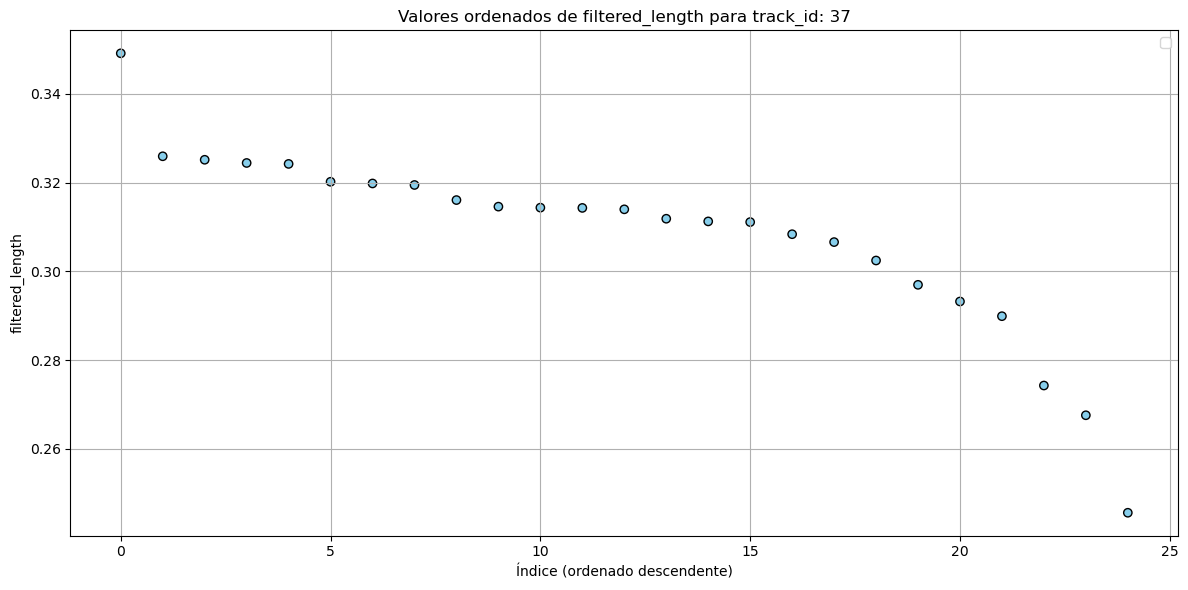

In [39]:
visualizar_outliers(df, 37, porcentaje_umbral=0.05)

In [ ]:
df_escenari_results

Tracks ids present in this video:
{1, 2, 34, 37, 6, 10, 27, 30, 31}
{1: 'lubina2', 2: 'ochoa_cinta', 34: 'fake_fish', 37: 'lubina2', 6: 'ochoa_no_cinta', 10: 'ochoa_no_cinta', 27: 'ochoa_no_cinta', 30: 'ochoa_no_cinta', 31: 'ochoa_cinta'}
  codi_escenari         day      hour frame_id  class_name  Object_id  \
0            E3  2025_05_08  11_57_58   frame7           9        127   
1            E3  2025_05_08  11_57_58   frame7           9        255   
2            E3  2025_05_08  11_57_58  frame14           9        127   
3            E3  2025_05_08  11_57_58  frame14           9        255   
4            E3  2025_05_08  11_57_58  frame15           9        127   

   track_id  is_3D_complete  in_image_borders  \
0         1               1             False   
1         2               1             False   
2         1               1             False   
3         2               1             False   
4         1               1             False   

                          f

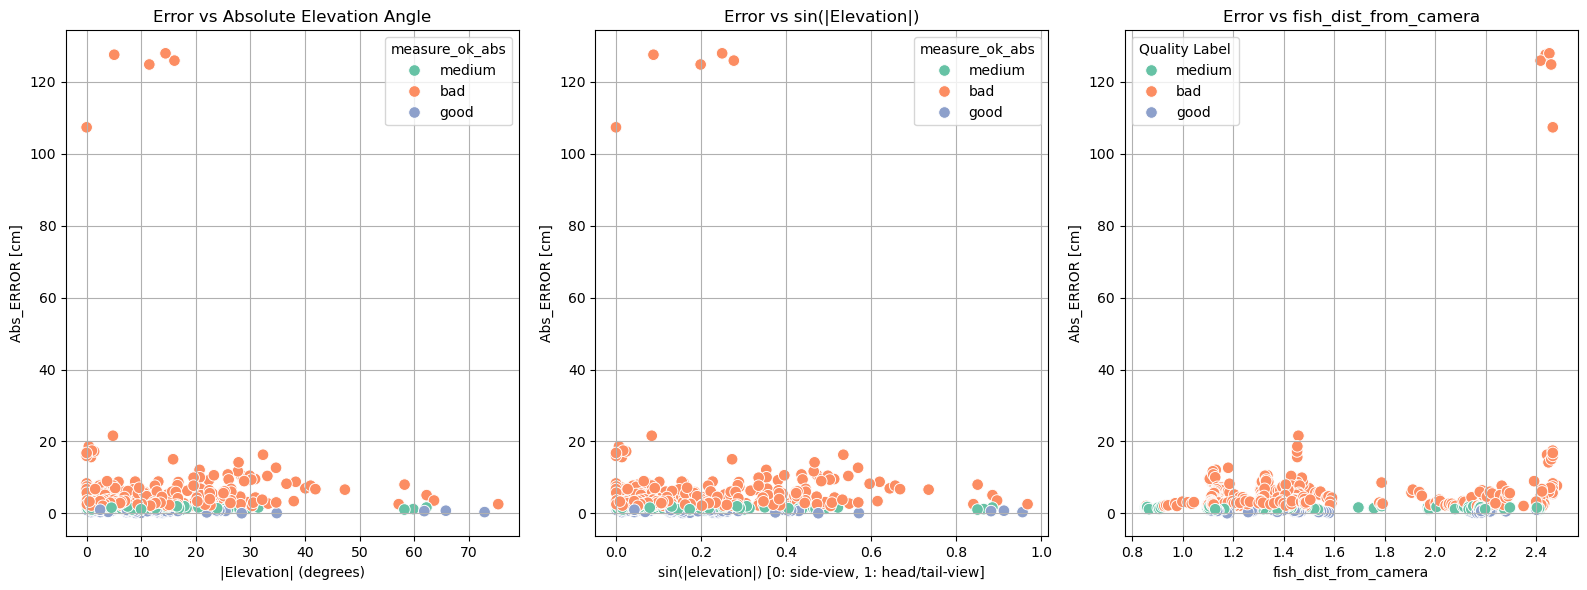

*****************************************
Maximo descartado 0.3776098577663251
*****************************************
*****************************************
Maximo descartado 0.4407713214462901
*****************************************
{1: 'lubina2', 2: 'ochoa_cinta', 34: 'fake_fish', 37: 'lubina2', 6: 'ochoa_no_cinta', 10: 'ochoa_no_cinta', 27: 'ochoa_no_cinta', 30: 'ochoa_no_cinta', 31: 'ochoa_cinta'}
peix_measures {'lubina0': 31.5, 'peix1': 19.4, 'caballa': 28.9, 'peix3': 21.6, 'lubina2': 33.5, 'ochoa_no_cinta': 30, 'ochoa_cinta': 33.5, 'fake_fish': -100, 'no_track_E2': 25}
------------------------------------------------------------------
   filtered_length  track_id  gt_measure codi_escenari         day      hour  \
0         0.346189         1        33.5            E3  2025_05_08  11_57_58   
1         0.326272         2        33.5            E3  2025_05_08  11_57_58   
2         0.212623         6        30.0            E3  2025_05_08  11_57_58   
3         0.304307     

/tmp/ipykernel_2399263/2128013161.py:156: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(filtrar_outliers)


In [49]:
# INICIALITZACIONS -----------------------------------------------------------
Escenari="Escenari_3/"
base_path="2025_05_08/11_57_58"

column_order = [
    "codi_escenari",
    "day",
    "hour",        
    "track_id",
    "count",
    "filtered_length",
    "gt_measure",
    "Abs_ERROR [cm]",
    "relative_error [%]",
    "measure_ok_abs",
    "max_length",
    "mean_length",
    "std_dev",
    "elevation_deg_mean",
    "comentaris"
]

df_all_results = pd.DataFrame(columns=column_order)


day = base_path.split("/")[0]
hour = base_path.split("/")[-1]
codi_escenari="E"+Escenari.split("_")[-1][0]

temp_code = ("-").join(base_path.split("/"))
experiment_code = codi_escenari+"_"+temp_code


out_escenari_agg_csv=codi_escenari+"_results_resume.csv"
out_csv_name =experiment_code+"_results_agg.csv"

df = pd.read_csv(Escenari+base_path+"/pointclouds/results/all_complete_ok_fish.csv").iloc[:,1:]
df_resume = pd.read_csv(Escenari+base_path+"/pointclouds/results/resume.csv")

df['codi_escenari'] = codi_escenari
df['day'] = day
df['hour'] = hour

# Paso 3: Reordenar columnas (poner las nuevas al principio)
cols = ['codi_escenari', 'day', 'hour'] + [col for col in df.columns if col not in ['codi_escenari', 'day', 'hour']]
df = df[cols]


peix_measures={"lubina0":31.5,"peix1":19.4,"caballa":28.9,"peix3":21.6,"lubina2":33.5,"ochoa_no_cinta":30,"ochoa_cinta":33.5,"fake_fish":-100,"no_track_E2":25}

bagfile_gts = { 
                "2024_11_18/13_52_03":{1:"caballa", 4:"caballa", 11:"peix1", 19:"peix1", 20:"peix1", 22:"caballa", 26:"peix1",\
                                       27:"caballa", 28:"caballa", 33:"peix1", 39:"caballa", 41:"peix1", \
                                       47:"peix1", 49:"peix3", 50:"peix1", 52:"caballa", 54:"peix1", 55:"peix3", 56:"peix1", 58:"peix1"},

                "2025_05_08/11_57_58":{1:"lubina2", 2:"ochoa_cinta", 34:"fake_fish", 37:"lubina2", 6:"ochoa_no_cinta", 10:"ochoa_no_cinta", 27:"ochoa_no_cinta",\
                                       30:"ochoa_no_cinta", 31:"ochoa_cinta"},
                # 11_48_14 -> Aquest es un poc trambòlico xq el tracker es confon quan es creuen peixos.
                "2025_05_08/11_48_14":{32:"ochoa_cinta", 1:"lubina2", 2:"ochoa_no_cinta", 3:"ochoa_cinta", 6:"ochoa_cinta", 8:"ochoa_cinta", 16:"ochoa_cinta", \
                                            19:"lubina2", 21:"ochoa_cinta", 22:"ochoa_no_cinta", 23:"lubina2", 28:"lubina2", 29:"ochoa_cinta", 30:"ochoa_cinta"},
                # Escenari_2
               "2025_05_08/11_30_34": {1:"ochoa_no_cinta", 4:"lubina2", 9:"ochoa_no_cinta", 18:"lubina2", 23:"fake_fish"},
               "2025_05_08/11_36_35":{1:"ochoa_no_cinta", 2:"lubina2", 5:"ochoa_no_cinta", 6:"lubina2", 12:"ochoa_no_cinta", 16:"ochoa_no_cinta", 18:"ochoa_no_cinta", 20:"ochoa_no_cinta", 24:"lubina2"},
               "2025_05_08/11_44_47":{1:"lubina2", 4:"ochoa_no_cinta", 14:"ochoa_no_cinta"},
               "2024_11_28/13_19_06":{1:"caballa", 2:"peix3", 8:"peix3", 9:"caballa", 10:"peix3", 11:"caballa", 15:"peix3", 19:"fake_fish"},
               "2024_11_28/13_47_08":{1:"caballa", 3:"peix3", 6:"peix3", 10:"caballa", 11:"peix3", -1:"no_track_E2"},
               #Escenari 1:
               "2025_05_08/11_17_18": {1: "lubina2", 6: "fake_fish", 9: "fake_fish"},
               "2025_05_08/11_41_03":{1:"lubina2"},
               "2024_11_12/11_00_27":{-1:"lubina0", 1:"lubina0", 2:"lubina0", 3:"lubina0", 6:"lubina0", 8:"lubina0", 11:"lubina0"},
               "2024_11_28/13_07_38":{1:"caballa" , -1:"caballa" , 6:"caballa"},
               "2024_11_28/13_09_20":{-1: "caballa" , 4: "caballa" , 5: "caballa"}}


# bagfile_gts = {"2025_05_08/11_30_34": {1:30, 4:33.5, 9:30, 18:33.5, 23:-100},
#                "2025_05_08/11_36_35":{1, 2, 5, 6, 12, 16, 18, 20, 24},
#                #Escenari 1:
#                "2025_05_08/11_17_18": {1: 33.5, 6: -100, 9: -100},
#                "2025_05_08/11_41_03":{1:33.5},
#                "2024_11_12/11_00_27":{-1:31.5, 1:31.5, 2:31.5, 3:31.5, 6:31.5, 8:31.5, 11:31.5},
#                "2024_11_28/13_07_38":{1:28.9 , -1:28.9 , 6:28.9},
#                "2024_11_28/13_09_20":{-1: 28.9 , 4: 28.9 , 5: 28.9}}
              
#----------------------------------------------------------------------------------

print("Tracks ids present in this video:")
print(set(df["track_id"]))

# Ja he generat el gt
if base_path in bagfile_gts.keys():

    gt_measure = bagfile_gts[base_path]
    print(gt_measure)
        
    
    df["gt_measure"] = df["track_id"].map(gt_measure).map(peix_measures)
    df_resume["gt_measure"] = df_resume["track_id"].map(gt_measure).map(peix_measures)
    # df_resume["gt_measure"] = df["track_id"].map(gt_measure[peix_measures])
    df.sort_values(by=['frame_id'])

    df["Abs_ERROR [cm]"]=abs(df["filtered_length"]-(df["gt_measure"]/100))*100
    df['Rel_ERROR[%]'] = df['Abs_ERROR [cm]'] / (df['gt_measure']/100)

    print(df.head())
    print("----------------------------------- \n \n")

    df = clasificar_medidas(df, agg=False)
    # print(df.head())
    
    df = generate_analysis_plots(df)

    # Descomentar para guardar todas las medidas sin agregar clasificadas:
    # styled_df = df.style.apply(lambda row: highlight_rows(row, quality_column="measure_ok_abs"), axis=1)
    # styled_df.to_excel(out_csv_name+'.xlsx', engine='openpyxl', index=False)

    df_resultado=descartar_outliers_por_track(df, porcentaje_umbral=0.1)
    print(df_resultado.head())
    

    df_resultado["Comentaris"] = ("")
    # df_resultado.loc[df_resultado["track_id"] != 1, "Comentaris"] = ("")

    df_resultado_colored = df_resultado.style.apply(lambda row: highlight_rows(row, quality_column='measure_ok_abs'), axis=1)
    
    


In [29]:
df_resultado_colored

,codi_escenari,day,hour,track_id,count,filtered_length,gt_measure,Abs_ERROR [cm],relative_error [%],measure_ok_abs,max_length,mean_length,std_dev,elevation_deg_mean,Comentaris
0,E3,2025_05_08,11_57_58,1,115,0.346189,33.500000,1.118862,3.339887,medium,0.377610,0.300030,0.037174,2.609643,
1,E3,2025_05_08,11_57_58,2,110,0.326272,33.500000,0.872780,2.605314,good,0.440771,0.301441,0.032317,0.865417,
2,E3,2025_05_08,11_57_58,6,4,0.212623,30.000000,8.737677,29.125589,bad,0.212623,0.200806,0.014887,12.915070,
3,E3,2025_05_08,11_57_58,10,77,0.304307,30.000000,0.430735,1.435785,good,0.304307,0.251926,0.031048,5.307926,
4,E3,2025_05_08,11_57_58,27,20,0.276993,30.000000,2.300663,7.668878,bad,0.276993,0.245419,0.043648,3.755053,
5,E3,2025_05_08,11_57_58,30,65,0.311920,30.000000,1.192032,3.973439,medium,0.311920,0.277398,0.027844,22.850089,
6,E3,2025_05_08,11_57_58,31,69,0.326525,33.500000,0.847489,2.529816,good,0.326525,0.306771,0.013334,-2.624519,
7,E3,2025_05_08,11_57_58,34,5,0.279771,-100.000000,127.977129,-127.977129,bad,0.279771,0.227567,0.086800,-2.980703,
8,E3,2025_05_08,11_57_58,37,25,0.349109,33.500000,1.410937,4.211752,medium,0.349109,0.308019,0.021289,5.794882,


In [35]:
# df_debug = df[(df['track_id'] == 27) & (df['filtered_length'] > 0.30)]
df_debug = df[(df['track_id'] == 27)]



# df_debug=df_debug.sort_values(by=['Abs_ERROR [cm]'],ascending=False)
df_debug=df_debug.sort_values(by=['frame_id'],ascending=False)
df_debug

,codi_escenari,day,hour,frame_id,class_name,Object_id,track_id,is_3D_complete,in_image_borders,fish_direction,...,filtered_length,fish_dist_from_camera,gt_measure,Abs_ERROR [cm],Rel_ERROR[%],measure_ok_abs,measure_ok_rel,elevation_abs,elevation_rad,elevation_sin
298,E3,2025_05_08,11_57_58,frame280,9,255,27,1,False,[-0.43751257 -0.89527664 0.08403855],...,0.084256,1.458879,30.0,21.574394,71.914645,bad,bad,4.820740,0.084138,0.084039
294,E3,2025_05_08,11_57_58,frame275,9,255,27,1,False,[-0.94366821 -0.32789686 -0.04442919],...,0.270884,1.449183,30.0,2.911630,9.705432,bad,bad,2.546443,-0.044444,0.044429
291,E3,2025_05_08,11_57_58,frame274,9,255,27,1,False,[-0.93863625 -0.34117868 -0.05058745],...,0.272923,1.448202,30.0,2.707676,9.025587,bad,bad,2.899685,-0.050609,0.050587
288,E3,2025_05_08,11_57_58,frame272,9,255,27,1,False,[-0.94293785 -0.32521909 -0.0714195 ],...,0.276993,1.447195,30.0,2.300663,7.668878,bad,bad,4.095523,-0.071480,0.071420
285,E3,2025_05_08,11_57_58,frame270,9,255,27,1,False,[-0.94906569 -0.30630931 -0.07381677],...,0.275718,1.445884,30.0,2.428169,8.093898,bad,bad,4.233240,-0.073884,0.073817
282,E3,2025_05_08,11_57_58,frame268,9,255,27,1,False,[-0.95090767 -0.30442354 -0.05568581],...,0.274085,1.446242,30.0,2.591545,8.638482,bad,bad,3.192213,-0.055715,0.055686
279,E3,2025_05_08,11_57_58,frame261,9,255,27,1,False,[-0.96879902 -0.22746397 -0.09843068],...,0.272480,1.447448,30.0,2.751950,9.173168,bad,bad,5.648809,-0.098590,0.098431
276,E3,2025_05_08,11_57_58,frame258,9,255,27,1,False,[-0.97928793 -0.19381667 -0.05856839],...,0.262742,1.443435,30.0,3.725799,12.419331,bad,bad,3.357643,-0.058602,0.058568
273,E3,2025_05_08,11_57_58,frame257,9,255,27,1,False,[-0.97900312 -0.19234901 -0.06748894],...,0.261212,1.444994,30.0,3.878787,12.929292,bad,bad,3.869773,-0.067540,0.067489
270,E3,2025_05_08,11_57_58,frame255,9,255,27,1,False,[-0.96854152 -0.23301585 -0.08735518],...,0.260568,1.448595,30.0,3.943175,13.143918,bad,bad,5.011470,-0.087467,0.087355


In [31]:
frame_id = 24
object_id=255

problematic_frames=[os.path.join(Escenari+base_path,file) for file in os.listdir(Escenari+base_path) if "frame"+str(frame_id)+"_" in file and (".jpg" in file or ".png" in file)]
debug_path=os.path.join(Escenari+base_path,"debug")
debug_files=[os.path.join(debug_path,file) for file in os.listdir(debug_path) if "frame"+str(frame_id)+"_" in file and str(object_id) in file and (".jpg" in file or ".png" in file)]
problematic_frames.extend(debug_files)
inferred_path=os.path.join(Escenari+base_path,"inferred")
inferred_files=[os.path.join(inferred_path,file) for file in os.listdir(inferred_path) if "frame"+str(frame_id)+"_" in file and str(object_id) in file and (".jpg" in file or ".png" in file)]
problematic_frames.extend(inferred_files)
problematic_frames

['Escenari_3/2025_05_08/11_57_58/frame24_masked.png',
 'Escenari_3/2025_05_08/11_57_58/frame24_right_image.jpg',
 'Escenari_3/2025_05_08/11_57_58/frame24_left_image.jpg',
 'Escenari_3/2025_05_08/11_57_58/frame24_object_ids.png',
 'Escenari_3/2025_05_08/11_57_58/frame24_disparity.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object_255_mask.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object255_contours_MASK.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object255_ellipse_DISPARITY.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object_255_mask_and_disp.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object255_ellipse_MASK.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object_255_ellipses.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object_255_disp.png',
 'Escenari_3/2025_05_08/11_57_58/debug/frame24_object255_contours_DISPARITY.png']

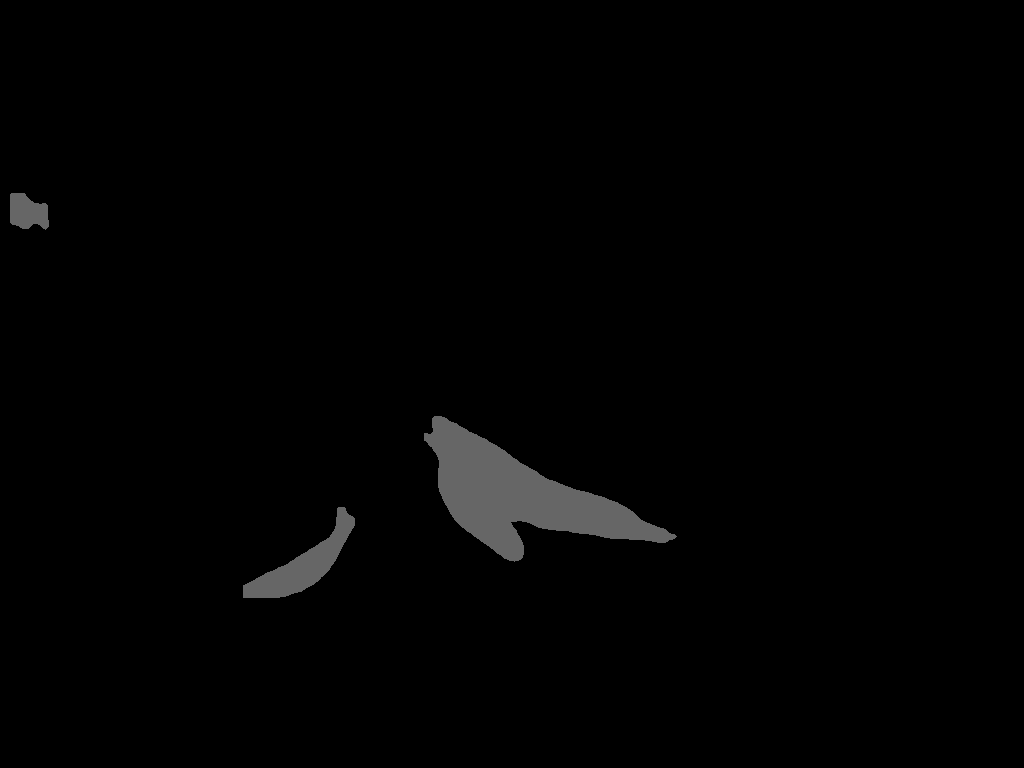

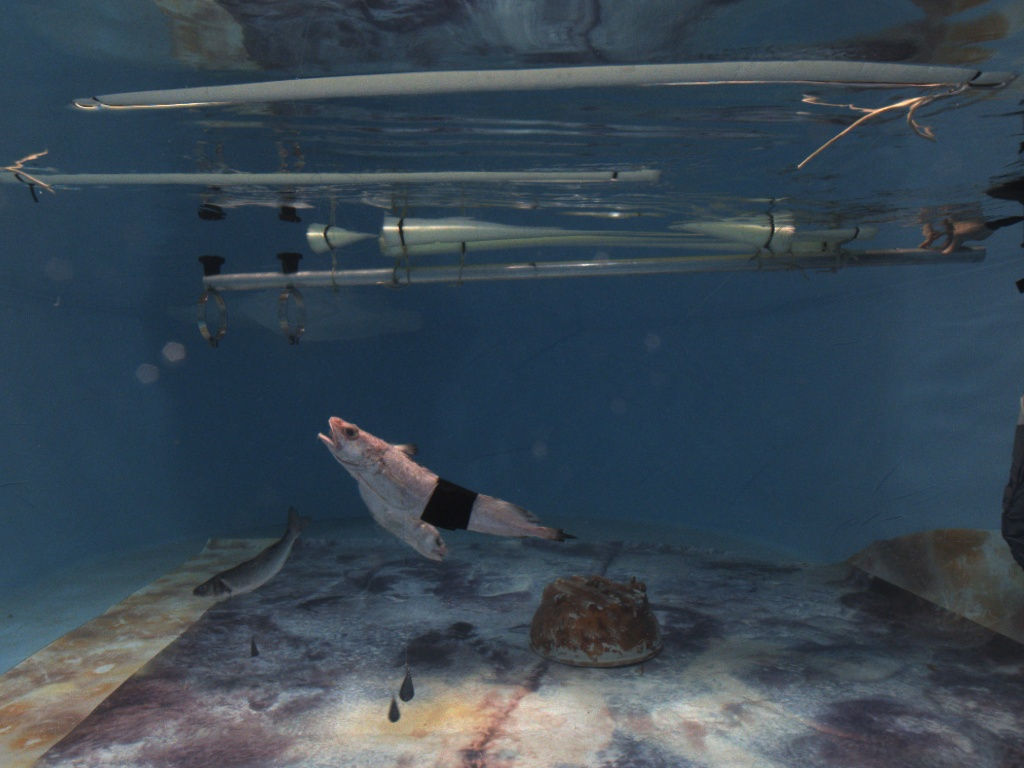

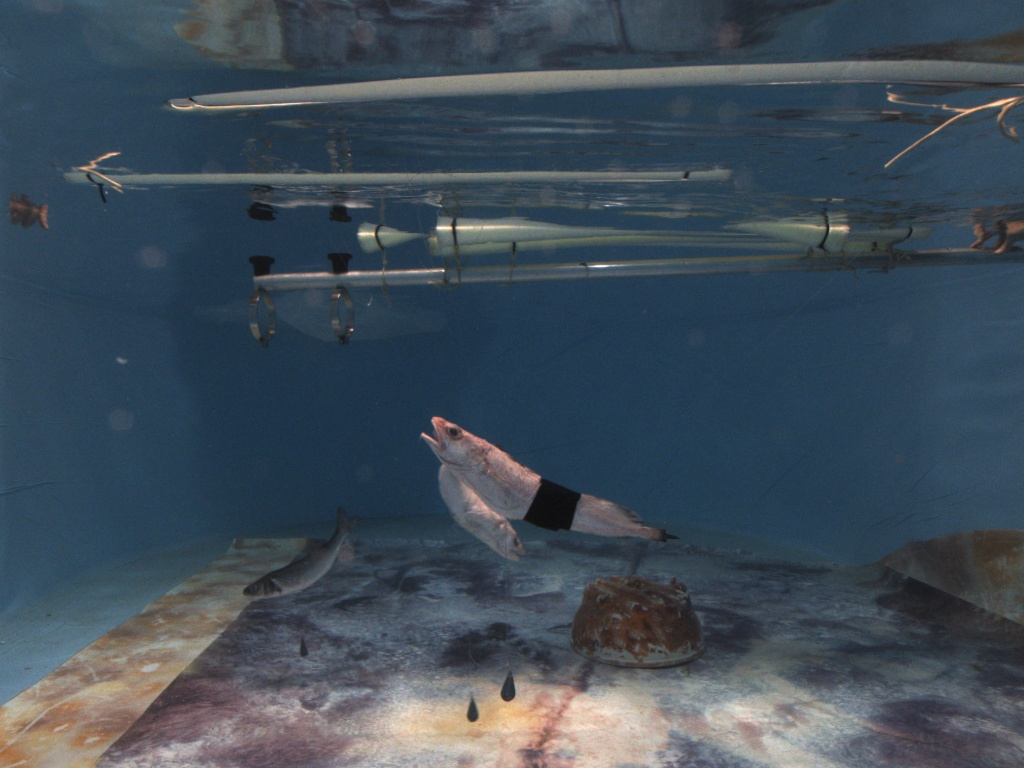

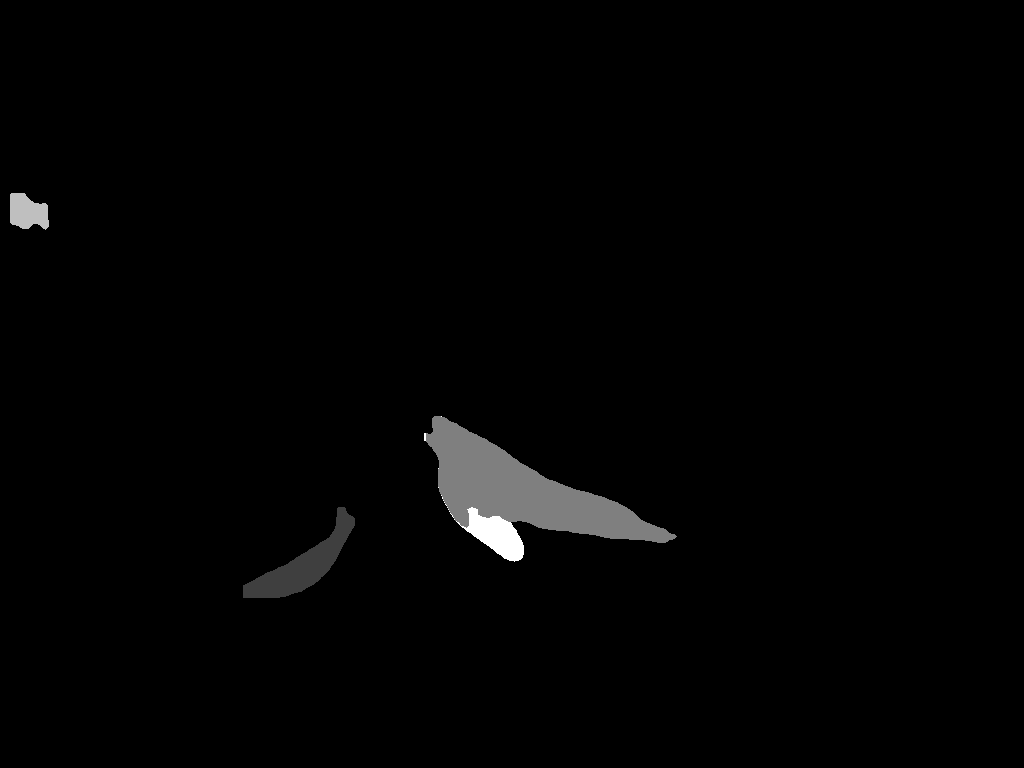

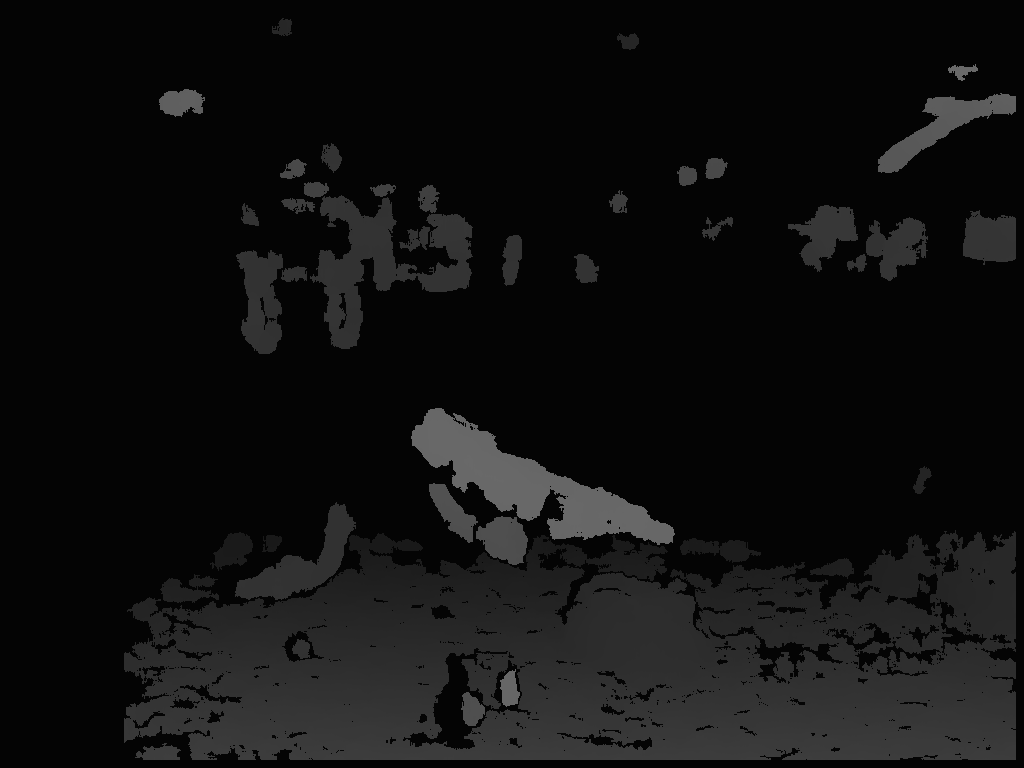

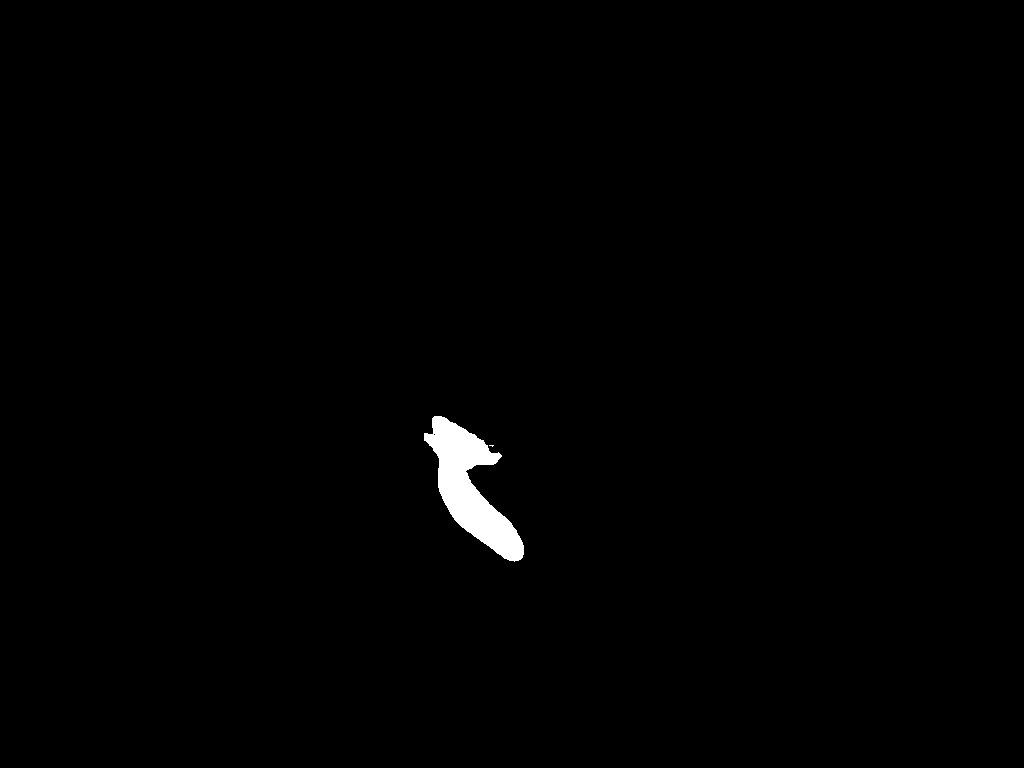

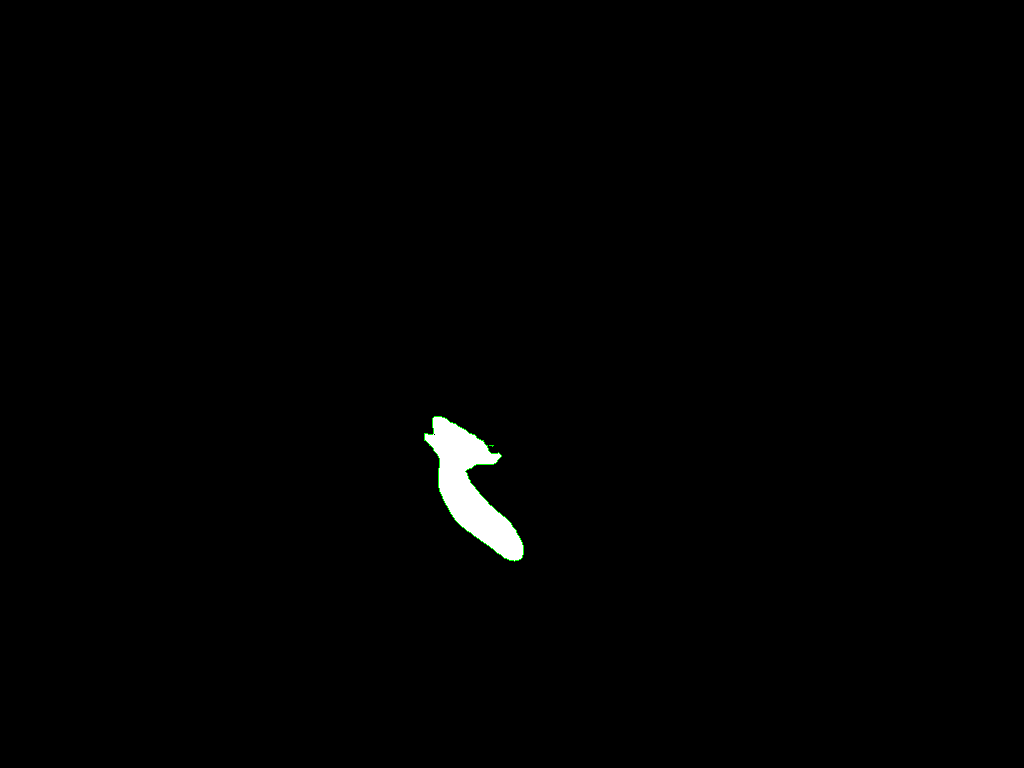

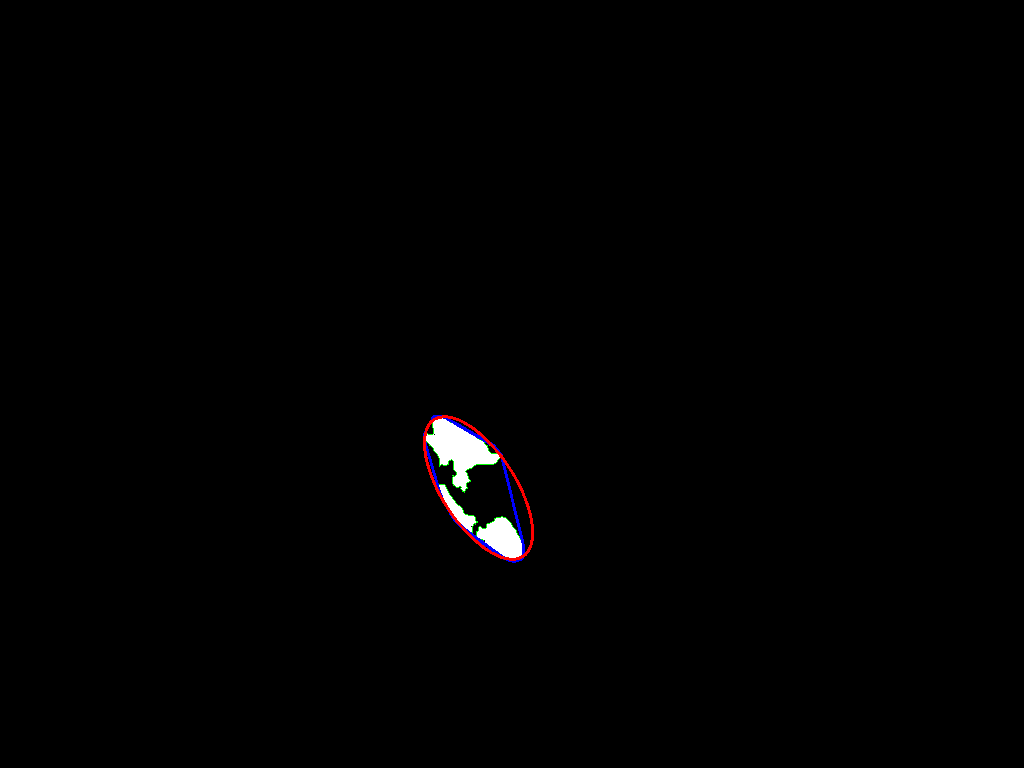

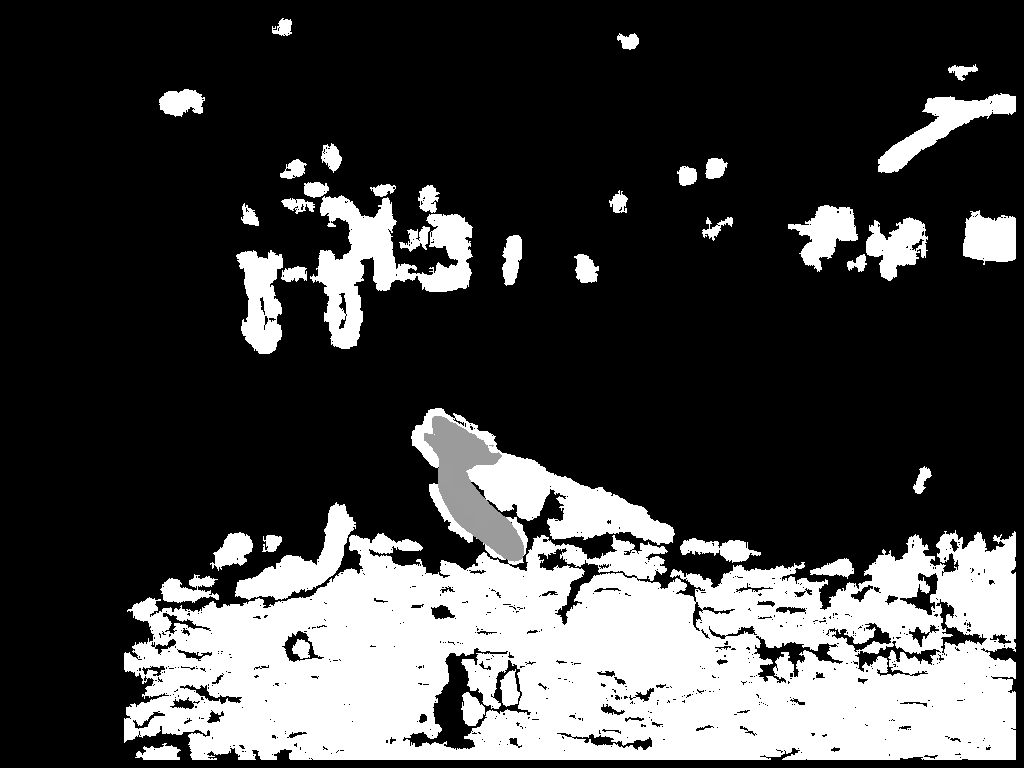

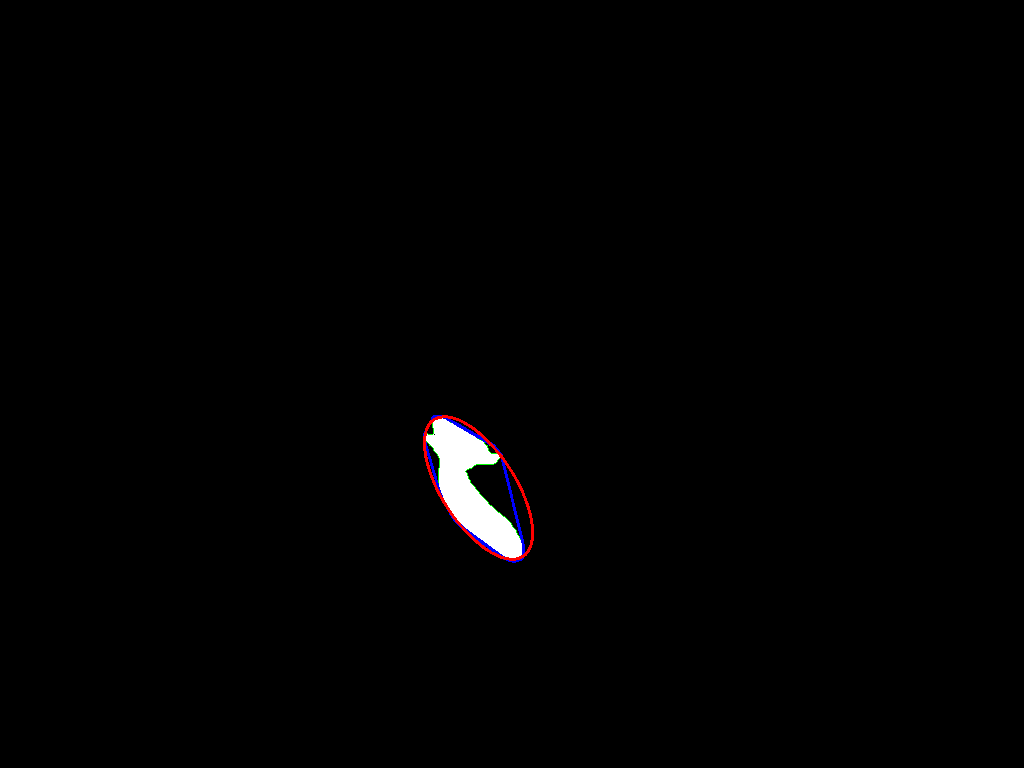

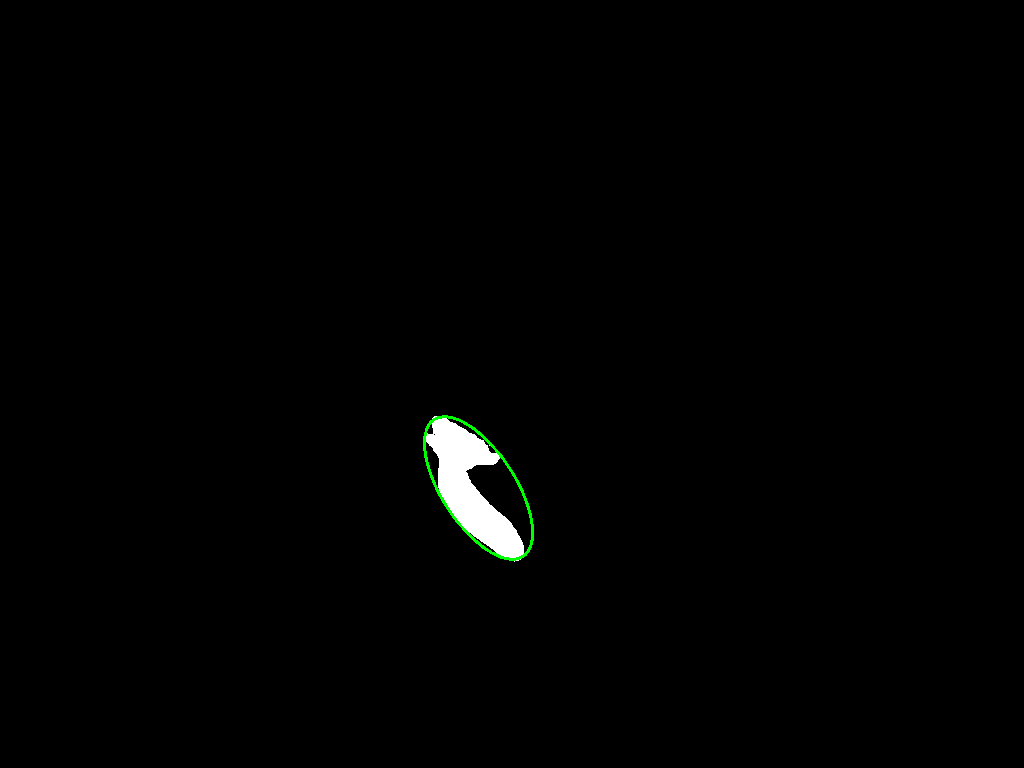

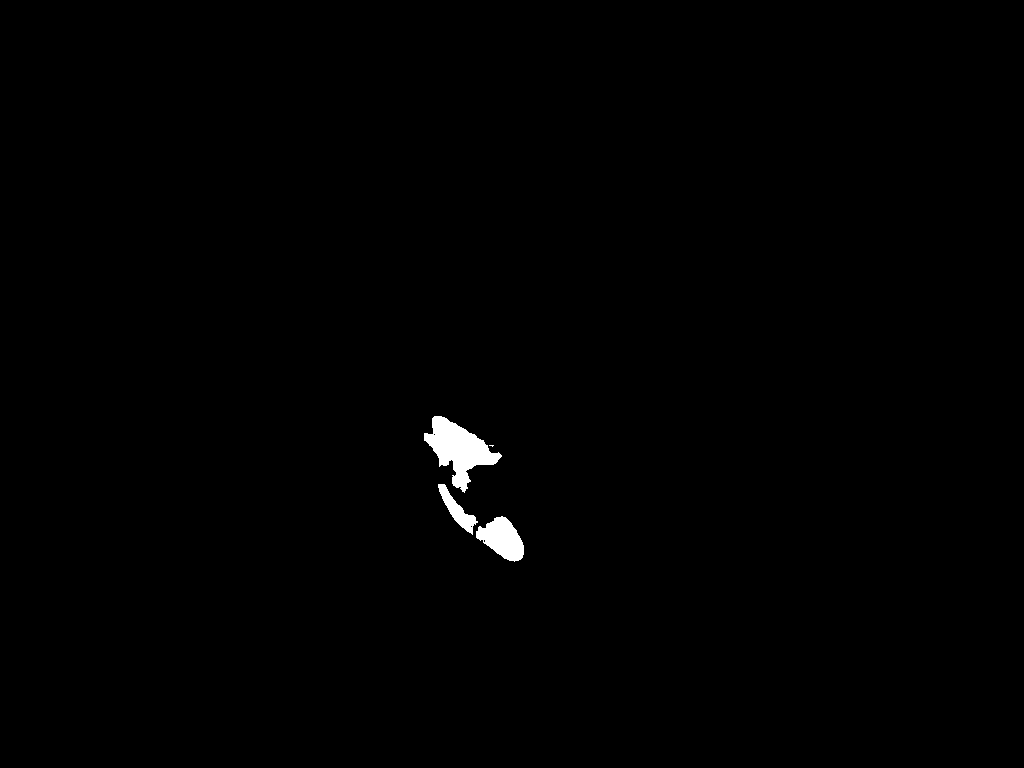

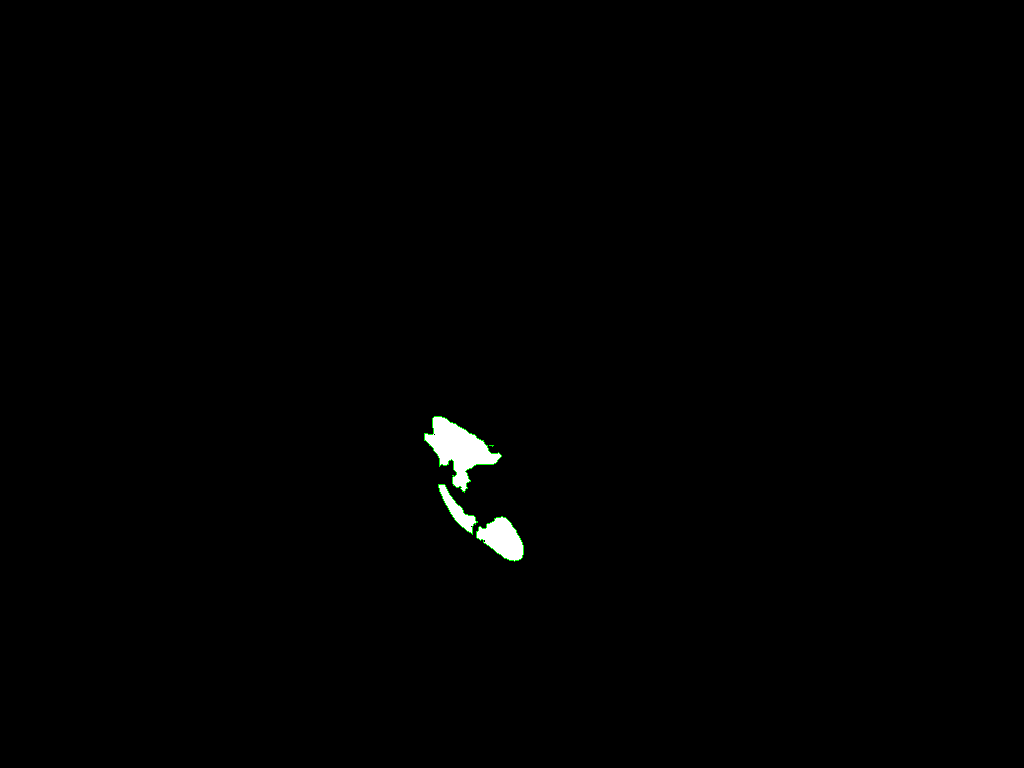

In [32]:
from IPython.display import Image

for imageName in problematic_frames:frame24frame24))